# 데이터 품질 / 입력 비교 실험 시각화

이 노트북은 `phase_experiments/` 아래의 결과 JSON을 자동으로 읽어서 두 가지를 시각화한다.

1. **데이터 품질 실험**: MLP 기준 `상`, `상+중`, `상+중+하` 비교  
   - phase F1 / phase acc
   - 종목(action) F1 / 종목(action) acc
   - count MAE

2. **입력/구조 비교**: MLP/LSTM 기준 `acc`, `vel`, `wrist`, `barbell`, `attn` 비교  
   - phase F1 / phase acc
   - 종목(action) F1 / 종목(action) acc
   - count MAE

> 참고: 현재 저장된 결과가 없는 조합은 `NaN`으로 표시된다. 특히 `상+중+하`, `wrist`는 실험 결과가 아직 없으면 자동으로 비어 보인다.

In [39]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

ROOT = Path.cwd()
EXP_ROOT = ROOT / "phase_experiments"
FIG_DIR = ROOT / "report_figures" / "model_quality_input_visualization"
SAVE_FIGURES = True

FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]

if HAS_SEABORN:
    sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

print("ROOT:", ROOT)
print("EXP_ROOT exists:", EXP_ROOT.exists())
print("seaborn:", HAS_SEABORN)

ROOT: C:\Users\kojy1\PycharmProjects\capstone
EXP_ROOT exists: True
seaborn: False


## 1. 결과 파일 로드

`ablation_results.json`, `derivative_input_results.json`, frame 재평가 JSON을 모두 읽는다.

In [40]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def as_records(obj):
    if obj is None:
        return []
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        # quality_run_manifest.json 같은 파일은 results 안에 실제 결과가 있음.
        if isinstance(obj.get("results"), list):
            return obj["results"]
        return [obj]
    return []


def add_records(rows, path: Path, records, source_kind: str):
    for i, r in enumerate(records):
        if not isinstance(r, dict):
            continue
        rr = dict(r)
        rr["_source_file"] = str(path)
        rr["_source_kind"] = source_kind
        rr["_source_index"] = i
        rows.append(rr)


rows = []

for path in sorted(EXP_ROOT.rglob("ablation_results.json")):
    add_records(rows, path, as_records(load_json(path)), "ablation_results")

for path in sorted(EXP_ROOT.rglob("derivative_input_results.json")):
    add_records(rows, path, as_records(load_json(path)), "derivative_input_results")

for path in sorted((EXP_ROOT / "frame_metric_reeval").glob("*.json")):
    add_records(rows, path, as_records(load_json(path)), "frame_metric_reeval")

df_raw = pd.DataFrame(rows)
print("loaded rows:", len(df_raw))
print("loaded files:", df_raw["_source_file"].nunique() if len(df_raw) else 0)
df_raw.head(3)

loaded rows: 27
loaded files: 15


,exp_name,model_type,phase_head_type,phase_pooling,derivative_mode,hidden,lstm_layers,clip_len,train_stride,dropout,...,frame_eval_stride,frame_action_acc,frame_action_f1,frame_phase_acc,frame_phase_f1,video_vote_action_acc,video_vote_action_f1,frame_action_acc_squat,frame_action_acc_benchpress,frame_action_acc_deadlift
0,barbell_barbell1_jall_mlp_h128_c16_pw_2.0_ts2_...,mlp,mlp,temporal_avg,pose,128.0,1.0,16.0,2.0,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...,mlp,mlp,temporal_avg,pose,128.0,1.0,16.0,2.0,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mediapipe_mediapipe33_jall_lstm_h128_c16_pw_2....,lstm,mlp,temporal_avg,pose,128.0,1.0,16.0,2.0,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. 공통 metric 컬럼 정리

과거 결과는 `video_action_f1`이 vote metric인 경우가 있고, 최신 재평가 결과는 `frame_action_f1`을 가진다.  
아래에서는 가능한 경우 frame metric을 우선하고, 없으면 기존 저장 metric을 fallback으로 사용한다.

In [41]:
def first_notna(row, cols, default=np.nan):
    for c in cols:
        if c in row and pd.notna(row[c]):
            return row[c]
    return default


def infer_quality_label(row):
    path = str(row.get("_source_file", "")).replace("\\", "/")
    levels = row.get("quality_levels", None)
    if isinstance(levels, list):
        s = set(map(str, levels))
        if {"상", "중", "하"} <= s:
            return "상+중+하"
        if {"상", "중"} <= s:
            return "상+중"
        if s == {"상"}:
            return "상"

    # Mojibake-safe path 기반 추론.
    if "/quality_filter/" in path:
        if "/high_mid_low/" in path or "/high_mid_low" in path or "/all/" in path:
            return "상+중+하"
        if "/high_mid/" in path:
            return "상+중"
        if "/high/" in path:
            return "상"
    if "quality_filter_best_arch" in path or "quality_high" in path:
        return "상"
    return None


def infer_dataset_scope(row):
    path = str(row.get("_source_file", "")).replace("\\", "/")
    q = infer_quality_label(row)
    if q:
        return q
    if "/derivative_input/" in path:
        return "전체/derivative"
    if "/yolo_pose/" in path:
        return "전체/yolo"
    if "/barbell_yolo_world/" in path:
        return "전체/barbell"
    return "기타"


def infer_input_variant(row):
    phase_aux = row.get("phase_aux_inputs", None)
    if isinstance(phase_aux, str) and phase_aux.strip():
        return "wrist" if "wrist" in phase_aux else phase_aux
    if isinstance(phase_aux, list) and len(phase_aux):
        if "wrist" in phase_aux:
            return "wrist"
        if "barbell" in phase_aux:
            return "barbell_aux"
        if "acceleration" in phase_aux:
            return "acc_aux"
        return "+".join(map(str, phase_aux))

    pose_backend = str(row.get("pose_backend", "")).lower()
    joint_subset = str(row.get("joint_subset", "")).lower()
    derivative = str(row.get("derivative_mode", "")).lower()
    phase_head = str(row.get("phase_head_type", "")).lower()

    if "wrist" in joint_subset:
        return "wrist"
    if pose_backend == "mediapipe_barbell":
        return "barbell"
    if derivative == "acceleration":
        return "acc"
    if derivative == "velocity":
        return "vel"
    if derivative == "velocity_acceleration":
        return "vel+acc"
    if phase_head == "exercise_attn":
        return "attn"
    if derivative == "pose":
        return "pose"
    return "unknown"


def normalize_model_type(row):
    m = row.get("model_type", None)
    if pd.isna(m) or m is None:
        name = str(row.get("exp_name", "")).lower()
        if "lstm" in name:
            return "lstm"
        if "mlp" in name:
            return "mlp"
    return str(m).lower()


def clean_numeric(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan


df = df_raw.copy()
if len(df):
    df["model_type_norm"] = df.apply(normalize_model_type, axis=1)
    df["quality_label"] = df.apply(infer_quality_label, axis=1)
    df["dataset_scope"] = df.apply(infer_dataset_scope, axis=1)
    df["input_variant"] = df.apply(infer_input_variant, axis=1)

    df["phase_f1_plot"] = df.apply(lambda r: first_notna(r, ["frame_phase_f1", "video_phase_f1", "phase_f1", "phase_macro_f1"]), axis=1).map(clean_numeric)
    df["phase_acc_plot"] = df.apply(lambda r: first_notna(r, ["frame_phase_acc", "video_phase_acc", "phase_acc"]), axis=1).map(clean_numeric)
    df["action_f1_plot"] = df.apply(lambda r: first_notna(r, ["frame_action_f1", "video_action_f1", "action_f1"]), axis=1).map(clean_numeric)
    df["action_acc_plot"] = df.apply(lambda r: first_notna(r, ["frame_action_acc", "video_action_acc", "action_acc"]), axis=1).map(clean_numeric)
    df["mae_plot"] = df.apply(lambda r: first_notna(r, ["video_count_mae", "count_mae"]), axis=1).map(clean_numeric)
    df["score_plot"] = df.apply(lambda r: first_notna(r, ["best_val_score"]), axis=1).map(clean_numeric)
    df["has_frame_metrics"] = df.apply(
        lambda r: pd.notna(first_notna(r, ["frame_action_f1", "frame_phase_f1"], default=np.nan)),
        axis=1,
    )

metric_cols = [
    "exp_name", "model_type_norm", "quality_label", "dataset_scope", "input_variant",
    "phase_f1_plot", "phase_acc_plot", "action_f1_plot", "action_acc_plot", "mae_plot",
    "best_val_score", "video_vote_action_f1", "has_frame_metrics", "_source_kind", "_source_file",
]
df[metric_cols].head(10)

,exp_name,model_type_norm,quality_label,dataset_scope,input_variant,phase_f1_plot,phase_acc_plot,action_f1_plot,action_acc_plot,mae_plot,best_val_score,video_vote_action_f1,has_frame_metrics,_source_kind,_source_file
0,barbell_barbell1_jall_mlp_h128_c16_pw_2.0_ts2_...,mlp,NaN,전체/barbell,pose,0.506184,0.508053,0.692063,0.738095,4.619048,1.059449,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
1,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...,mlp,상,상,pose,0.693525,0.691143,1.000000,1.000000,1.000000,1.608320,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
2,mediapipe_mediapipe33_jall_lstm_h128_c16_pw_2....,lstm,상,상,pose,0.715424,0.714395,1.000000,1.000000,0.666667,1.654463,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
3,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...,mlp,상+중,상+중,pose,0.660565,0.666513,1.000000,1.000000,1.750000,1.580946,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
4,mediapipe_mediapipe33_jall_lstm_h128_c16_pw_2....,lstm,상+중,상+중,pose,0.645184,0.647810,1.000000,1.000000,1.500000,1.540762,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
5,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...,mlp,상,상,acc,0.700703,0.698333,1.000000,1.000000,1.333333,1.638193,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
6,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...,mlp,상,상,attn,0.742385,0.744378,1.000000,1.000000,1.000000,1.663235,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
7,mediapipe_barbell_mediapipe33_barbell34_wrists...,mlp,상,상,barbell,0.745370,0.747591,1.000000,1.000000,0.866667,1.675994,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
8,mediapipe_mediapipe33_jall_lstm_h128_c16_pw_2....,lstm,상,상,acc,0.728693,0.728163,1.000000,1.000000,0.666667,1.665728,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...
9,mediapipe_mediapipe33_jall_lstm_h128_c16_pw_2....,lstm,상,상,attn,0.722749,0.726633,1.000000,1.000000,0.866667,1.662344,NaN,False,ablation_results,C:\Users\kojy1\PycharmProjects\capstone\phase_...


## 3. 데이터 품질 실험: MLP 상 / 상+중 / 상+중+하

현재 저장된 결과 중 `phase_experiments/quality_filter/...` 아래의 MLP 결과를 사용한다.  
`상+중+하` 결과가 없으면 표와 그래프에서 빈 값으로 나온다.

In [42]:
GREY = "#B8B8B8"
TEAL = "#008C8C"
quality_order  = ["상+중+하", "상+중", "상"]
quality_labels = ["상+중+하\n(baseline)", "상+중", "상\n(고품질)"]
bar_colors     = [GREY, "#7EB8B0", TEAL]

quality_df = df[
    (df["model_type_norm"] == "mlp")
    & (df["quality_label"].isin(quality_order))
    & (df["_source_file"].str.replace("\\", "/", regex=False).str.contains("/quality_filter/"))
].copy()

# 같은 quality/model 조합이 여러 개면 best_val_score가 높은 행을 대표로 사용.
quality_df = (
    quality_df.sort_values(["quality_label", "score_plot"], ascending=[True, False])
    .drop_duplicates(["quality_label", "model_type_norm"], keep="first")
)

quality_df = quality_df.set_index("quality_label").reindex(quality_order).reset_index()
quality_df["model_type_norm"] = quality_df["model_type_norm"].fillna("mlp")

# `상+중+하` quality-filter run이 따로 없으면, 전체/full MLP pose baseline을
# 상+중+하 baseline으로 채운다. 정확히 quality workbook 기준 상+중+하를 쓰려면
# high+medium+low quality-filter 실험을 별도로 돌리면 된다.
missing_all = quality_df.loc[quality_df["quality_label"] == "상+중+하", "phase_f1_plot"].isna().any()
if missing_all:
    full_baseline = df[
        (df["_source_kind"] == "derivative_input_results")
        & (df["model_type_norm"] == "mlp")
        & (df["derivative_mode"].astype(str).str.lower() == "pose")
    ].copy()
    if len(full_baseline):
        baseline_row = full_baseline.sort_values("score_plot", ascending=False).iloc[0]
        fill_idx = quality_df.index[quality_df["quality_label"] == "상+중+하"][0]
        for col in quality_df.columns:
            if col in baseline_row.index and col != "quality_label":
                quality_df.loc[fill_idx, col] = baseline_row[col]
        quality_df.loc[fill_idx, "quality_label"] = "상+중+하"
        quality_df.loc[fill_idx, "dataset_scope"] = "전체/full baseline"
        quality_df.loc[fill_idx, "baseline_note"] = "filled_from_derivative_input_full_pose_mlp"

quality_df["plot_label"] = quality_labels
quality_df["bar_color"] = bar_colors

display_cols = [
    "quality_label", "model_type_norm", "phase_f1_plot", "phase_acc_plot",
    "action_f1_plot", "action_acc_plot", "mae_plot", "score_plot", "dataset_scope", "baseline_note", "plot_label", "exp_name"
]
quality_df[display_cols]

,quality_label,model_type_norm,phase_f1_plot,phase_acc_plot,action_f1_plot,action_acc_plot,mae_plot,score_plot,dataset_scope,baseline_note,plot_label,exp_name
0,상+중+하,mlp,0.656728,0.655616,0.960688,0.97619,2.047619,1.551639,전체/full baseline,filled_from_derivative_input_full_pose_mlp,상+중+하\n(baseline),mlp_h128_c16_pw_2.0_ts2_do03_aug1
1,상+중,mlp,0.660565,0.666513,1.000000,1.00000,1.750000,1.580946,상+중,NaN,상+중,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...
2,상,mlp,0.693525,0.691143,1.000000,1.00000,1.000000,1.608320,상,NaN,상\n(고품질),mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...


saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\model_quality_input_visualization\quality_mlp_phase_action_mae.png


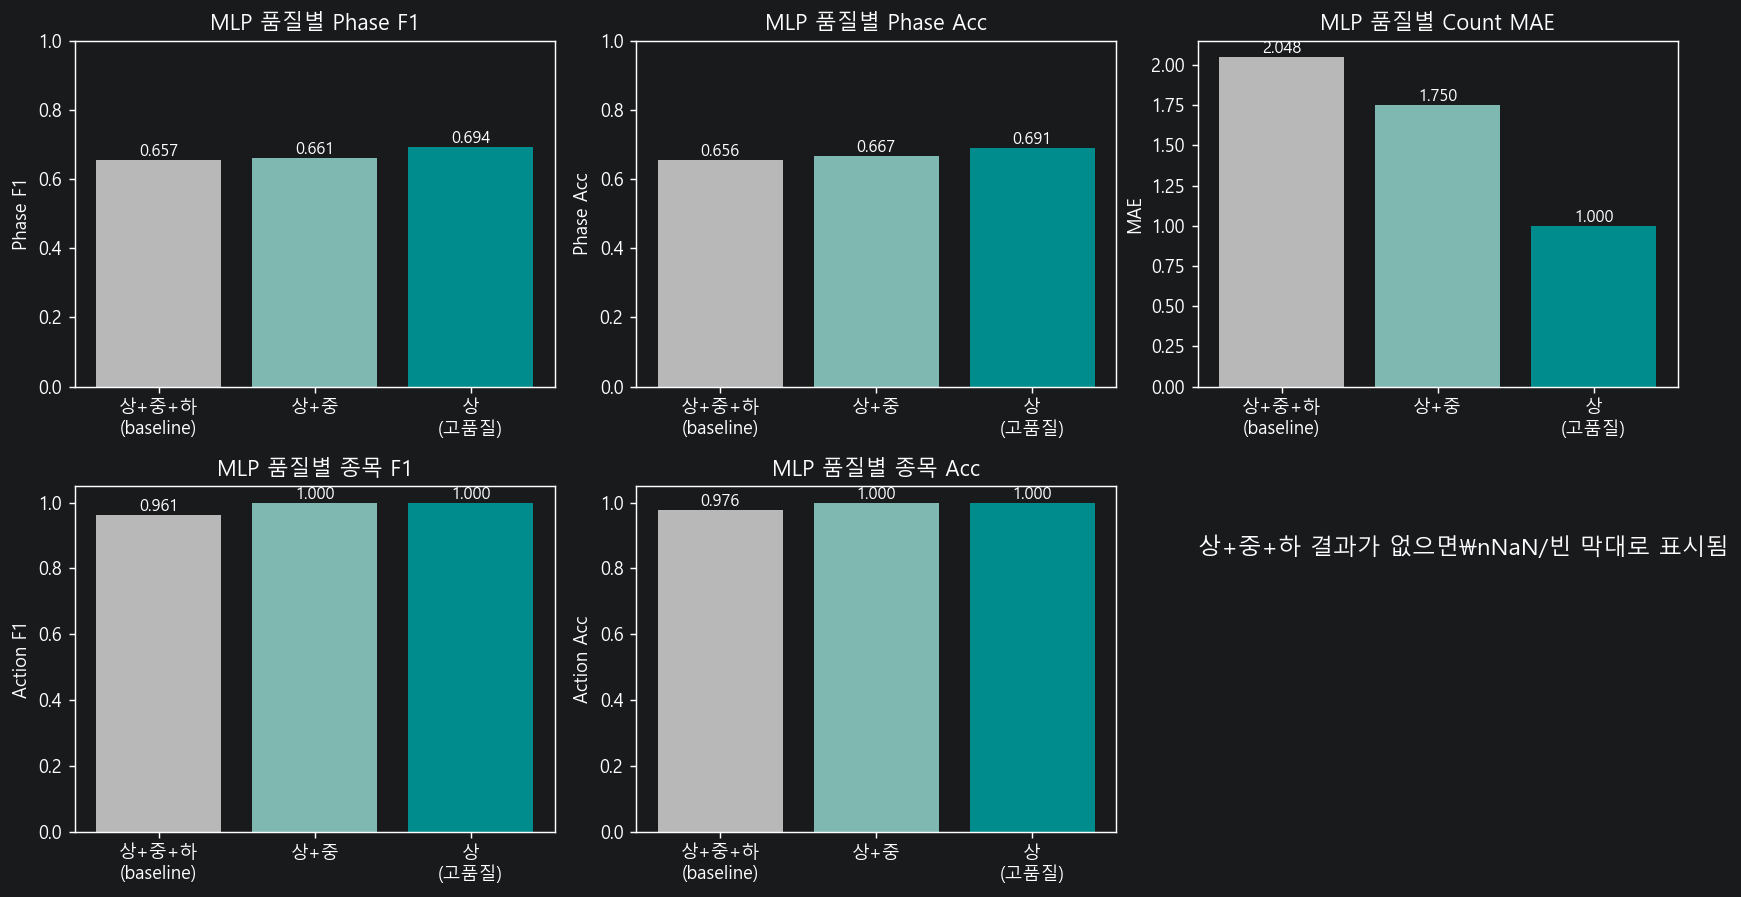

In [43]:
def savefig(name):
    if SAVE_FIGURES:
        path = FIG_DIR / name
        plt.savefig(path, bbox_inches="tight")
        print("saved:", path)


def barplot_simple(ax, data, x, y, title, ylabel=None, color="#4C78A8", lower_is_better=False):
    plot_data = data.copy()
    colors = plot_data["bar_color"] if "bar_color" in plot_data.columns else color
    ax.bar(plot_data[x].astype(str), plot_data[y], color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel or y)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(plot_data[y]):
        if pd.notna(v):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    if not lower_is_better:
        ax.set_ylim(0, min(1.05, max(1.0, np.nanmax(plot_data[y].to_numpy(dtype=float)) * 1.15 if plot_data[y].notna().any() else 1.0)))


fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

barplot_simple(axes[0], quality_df, "plot_label", "phase_f1_plot", "MLP 품질별 Phase F1", "Phase F1", "#4C78A8")
barplot_simple(axes[1], quality_df, "plot_label", "phase_acc_plot", "MLP 품질별 Phase Acc", "Phase Acc", "#72B7B2")
barplot_simple(axes[2], quality_df, "plot_label", "mae_plot", "MLP 품질별 Count MAE", "MAE", "#F58518", lower_is_better=True)
barplot_simple(axes[3], quality_df, "plot_label", "action_f1_plot", "MLP 품질별 종목 F1", "Action F1", "#54A24B")
barplot_simple(axes[4], quality_df, "plot_label", "action_acc_plot", "MLP 품질별 종목 Acc", "Action Acc", "#B279A2")
axes[5].axis("off")
axes[5].text(0, 0.8, "상+중+하 결과가 없으면\\nNaN/빈 막대로 표시됨", fontsize=13)

plt.tight_layout()
savefig("quality_mlp_phase_action_mae.png")
plt.show()

## 4. 입력/구조 비교: MLP / LSTM × acc / vel / wrist / barbell / attn

여기서는 저장된 전체 결과에서 `input_variant`를 추론한다.

- `acc`: acceleration 입력
- `vel`: velocity 입력
- `wrist`: wrist-only 또는 phase aux wrist
- `barbell`: MediaPipe33 + barbell fusion
- `attn`: MediaPipe pose + exercise attention

서로 다른 실험군이 섞일 수 있으므로 `dataset_scope`를 반드시 같이 확인한다.

In [44]:
variant_order = ["acc", "vel", "wrist", "barbell", "attn"]
model_order = ["mlp", "lstm"]

candidate = df[
    df["model_type_norm"].isin(model_order)
    & df["input_variant"].isin(variant_order)
].copy()

# 후보가 너무 많으면 model_type/input_variant별로 대표 행을 선택.
# 같은 score라면 기존 vote 지표보다 frame 재평가 지표가 있는 행을 우선한다.
candidate["_rank_metric"] = candidate["score_plot"].fillna(candidate["phase_f1_plot"]).fillna(-999)
input_df = (
    candidate.sort_values(
        ["model_type_norm", "input_variant", "has_frame_metrics", "_rank_metric"],
        ascending=[True, True, False, False],
    )
    .drop_duplicates(["model_type_norm", "input_variant"], keep="first")
)

full_index = pd.MultiIndex.from_product([model_order, variant_order], names=["model_type_norm", "input_variant"])
input_df = (
    input_df.set_index(["model_type_norm", "input_variant"])
    .reindex(full_index)
    .reset_index()
)

display_cols = [
    "model_type_norm", "input_variant", "dataset_scope", "phase_f1_plot", "phase_acc_plot",
    "action_f1_plot", "action_acc_plot", "mae_plot", "score_plot", "exp_name", "_source_file"
]
input_df[display_cols]

,model_type_norm,input_variant,dataset_scope,phase_f1_plot,phase_acc_plot,action_f1_plot,action_acc_plot,mae_plot,score_plot,exp_name,_source_file
0,mlp,acc,상,0.711674,0.709194,0.924435,0.959767,1.466667,1.638193,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...,C:\Users\kojy1\PycharmProjects\capstone\phase_...
1,mlp,vel,전체/derivative,0.644664,0.642980,1.000000,1.000000,1.761905,1.567605,mlp_h128_c16_pw_2.0_ts2_do03_aug1_input_velocity,C:\Users\kojy1\PycharmProjects\capstone\phase_...
2,mlp,wrist,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mlp,barbell,상,0.756071,0.758452,0.922332,0.957626,1.066667,1.675994,mediapipe_barbell_mediapipe33_barbell34_wrists...,C:\Users\kojy1\PycharmProjects\capstone\phase_...
4,mlp,attn,상,0.751452,0.753557,0.911905,0.949977,1.400000,1.663235,mediapipe_mediapipe33_jall_mlp_h128_c16_pw_2.0...,C:\Users\kojy1\PycharmProjects\capstone\phase_...
5,lstm,acc,상,0.738847,0.738412,0.927924,0.962980,0.533333,1.665728,mediapipe_mediapipe33_jall_lstm_h128_c16_pw_2....,C:\Users\kojy1\PycharmProjects\capstone\phase_...
6,lstm,vel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,lstm,wrist,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,lstm,barbell,상,0.753895,0.759064,0.927382,0.963898,1.333333,1.678739,mediapipe_barbell_mediapipe33_barbell34_wrists...,C:\Users\kojy1\PycharmProjects\capstone\phase_...
9,lstm,attn,상,0.734078,0.738106,0.931882,0.959767,0.866667,1.662344,mediapipe_mediapipe33_jall_lstm_h128_c16_pw_2....,C:\Users\kojy1\PycharmProjects\capstone\phase_...


In [45]:
missing = input_df[input_df["phase_f1_plot"].isna()][["model_type_norm", "input_variant"]]
if len(missing):
    print("아직 결과가 없는 조합:")
    display(missing)
else:
    print("요청한 모든 조합에 결과가 있습니다.")

아직 결과가 없는 조합:


,model_type_norm,input_variant
2,mlp,wrist
6,lstm,vel
7,lstm,wrist


  quality_bucket  phase_f1_plot  mae_plot  score_plot  \
0          상+중+하       0.656728  2.047619    1.551639   
1            상+중       0.660565  1.750000    1.580946   
2              상       0.693525  1.000000    1.608320   

                                        _source_file  
0  C:\Users\kojy1\PycharmProjects\capstone\phase_...  
1  C:\Users\kojy1\PycharmProjects\capstone\phase_...  
2  C:\Users\kojy1\PycharmProjects\capstone\phase_...  
saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\model_quality_input_visualization\ppt_quality_filter.png


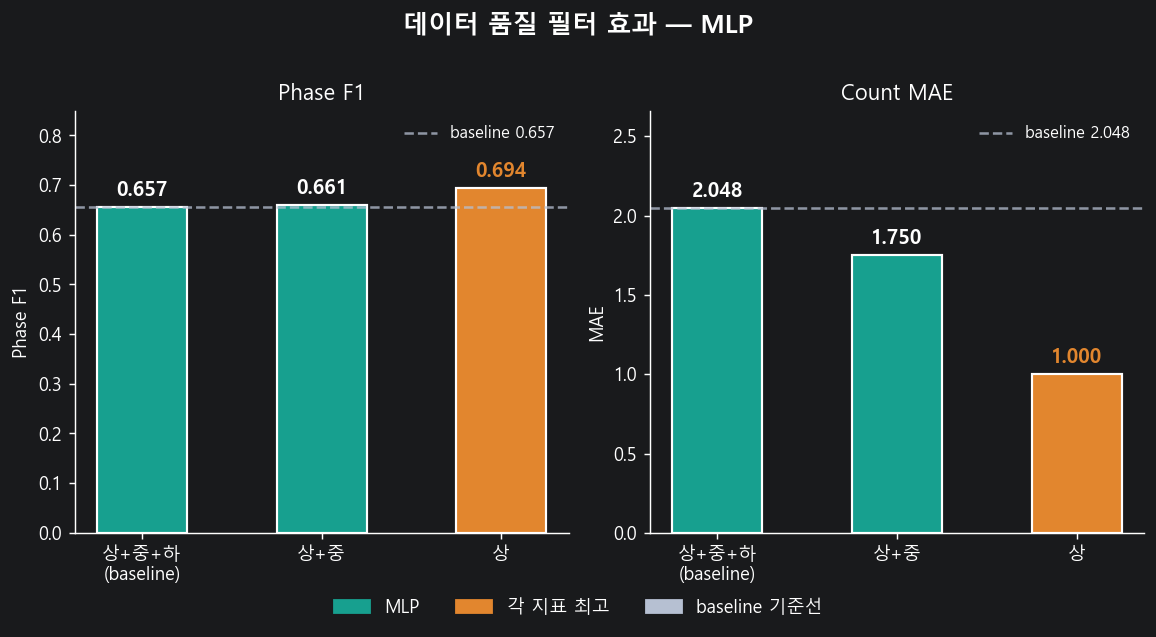

In [58]:
# ── 슬라이드 A: 품질 필터 효과 (MLP · pose 고정) ─────────────
# 상+중+하 = quality_filter 이전 실험 (baseline)
# 상+중, 상 = quality_filter 실험

NAVY   = "#FFFFFF"
TEAL   = "#17A08F"
GREY   = "#B6C0D2"
ORANGE = "#E2862E"

def assign_quality_bucket(row):
    ql  = row.get("quality_label", None)
    src = str(row.get("_source_file", "")).replace("\\", "/")
    if ql == "상":
        return "상"
    if ql == "상+중":
        return "상+중"
    if "/quality_filter/" not in src:
        return "상+중+하"
    return None

mlp_pose = df[
    (df["model_type_norm"] == "mlp") &
    (df["input_variant"] == "pose")
].copy()

mlp_pose["quality_bucket"] = mlp_pose.apply(assign_quality_bucket, axis=1)
mlp_pose = mlp_pose[mlp_pose["quality_bucket"].notna()]

quality_order  = ["상+중+하", "상+중", "상"]
quality_labels = ["상+중+하\n(baseline)", "상+중", "상\n"]

q_plot = (
    mlp_pose
    .sort_values(["quality_bucket", "score_plot"], ascending=[True, False])
    .drop_duplicates("quality_bucket", keep="first")
    .set_index("quality_bucket")
    .reindex(quality_order)
    .reset_index()
)

print(q_plot[["quality_bucket", "phase_f1_plot", "mae_plot", "score_plot", "_source_file"]])

# ── 각 지표별 best index ──
phase_vals = q_plot["phase_f1_plot"].tolist()
mae_vals   = q_plot["mae_plot"].tolist()

best_phase_idx = int(pd.Series(phase_vals).idxmax()) \
    if any(pd.notna(v) for v in phase_vals) else None

best_mae_idx = int(pd.Series(mae_vals).idxmin()) \
    if any(pd.notna(v) for v in mae_vals) else None

def metric_colors(best_idx):
    return [
        ORANGE if i == best_idx else TEAL
        for i in range(len(quality_order))
    ]

phase_colors = metric_colors(best_phase_idx)
mae_colors   = metric_colors(best_mae_idx)

# ── 그래프 ──
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
fig.suptitle("데이터 품질 필터 효과 — MLP",
             fontsize=14, fontweight="bold", color=NAVY, y=1.01)

def annotate(ax, bars, vals, best_idx, fmt=".3f", pad=0.01):
    for i, (b, v) in enumerate(zip(bars, vals)):
        if pd.notna(v):
            ax.text(
                b.get_x() + b.get_width() / 2,
                v + pad,
                f"{v:{fmt}}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                color=ORANGE if i == best_idx else NAVY
            )

# ── Phase F1 ──
ax = axes[0]
base = phase_vals[0]

bars = ax.bar(
    quality_labels,
    phase_vals,
    color=phase_colors,
    width=0.5,
    edgecolor="white",
    linewidth=1.2
)

if pd.notna(base):
    ax.axhline(
        base,
        color=GREY,
        linewidth=1.4,
        linestyle="--",
        alpha=0.75,
        label=f"baseline {base:.3f}"
    )
    ax.legend(fontsize=9, frameon=False)

ax.set_title("Phase F1", fontsize=12, color=NAVY)
ax.set_ylim(0, 0.85)
ax.set_ylabel("Phase F1", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
annotate(ax, bars, phase_vals, best_phase_idx, pad=0.012)

# ── Count MAE ──
ax = axes[1]
base2 = mae_vals[0]

bars2 = ax.bar(
    quality_labels,
    mae_vals,
    color=mae_colors,
    width=0.5,
    edgecolor="white",
    linewidth=1.2
)

if pd.notna(base2):
    ax.axhline(
        base2,
        color=GREY,
        linewidth=1.4,
        linestyle="--",
        alpha=0.75,
        label=f"baseline {base2:.3f}"
    )
    ax.legend(fontsize=9, frameon=False)

ax.set_title("Count MAE", fontsize=12, color=NAVY)
ax.set_ylim(0, max([v for v in mae_vals if pd.notna(v)] or [2]) * 1.3)
ax.set_ylabel("MAE", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
annotate(ax, bars2, mae_vals, best_mae_idx, fmt=".3f", pad=0.04)

# ── 범례 ──
from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(color=TEAL, label="MLP"),
        Patch(color=ORANGE, label="각 지표 최고"),
        Patch(color=GREY, label="baseline 기준선"),
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.05)
)

fig.tight_layout()

if SAVE_FIGURES:
    out = FIG_DIR / "ppt_quality_filter.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    print("saved:", out)

plt.show()

## 5. Heatmap 요약

phase F1과 MAE를 모델 × 입력 조합으로 확인한다.

reeval rows: 6
   model_type_norm input_variant  phase_f1_plot  action_f1_plot  mae_plot  obo_plot
21             mlp           acc       0.711674        0.924435  1.466667  0.800000
22             mlp          attn       0.751452        0.911905  1.400000  0.933333
23             mlp       barbell       0.756071        0.922332  1.066667  0.866667
24            lstm           acc       0.738847        0.927924  0.533333  0.933333
25            lstm          attn       0.734078        0.931882  0.866667  0.800000
26            lstm       barbell       0.753895        0.927382  1.333333  0.866667
     label_disp  phase_f1_plot  mae_plot  action_f1_plot  obo_plot
0    MLP\naccel       0.711674  1.466667        0.924435  0.800000
1   MLP\nattn *       0.751452  1.400000        0.911905  0.933333
2   MLP\nfusion       0.756071  1.066667        0.922332  0.866667
3   LSTM\naccel       0.738847  0.533333        0.927924  0.933333
4  LSTM\nattn *       0.734078  0.866667        0.931882  0.80

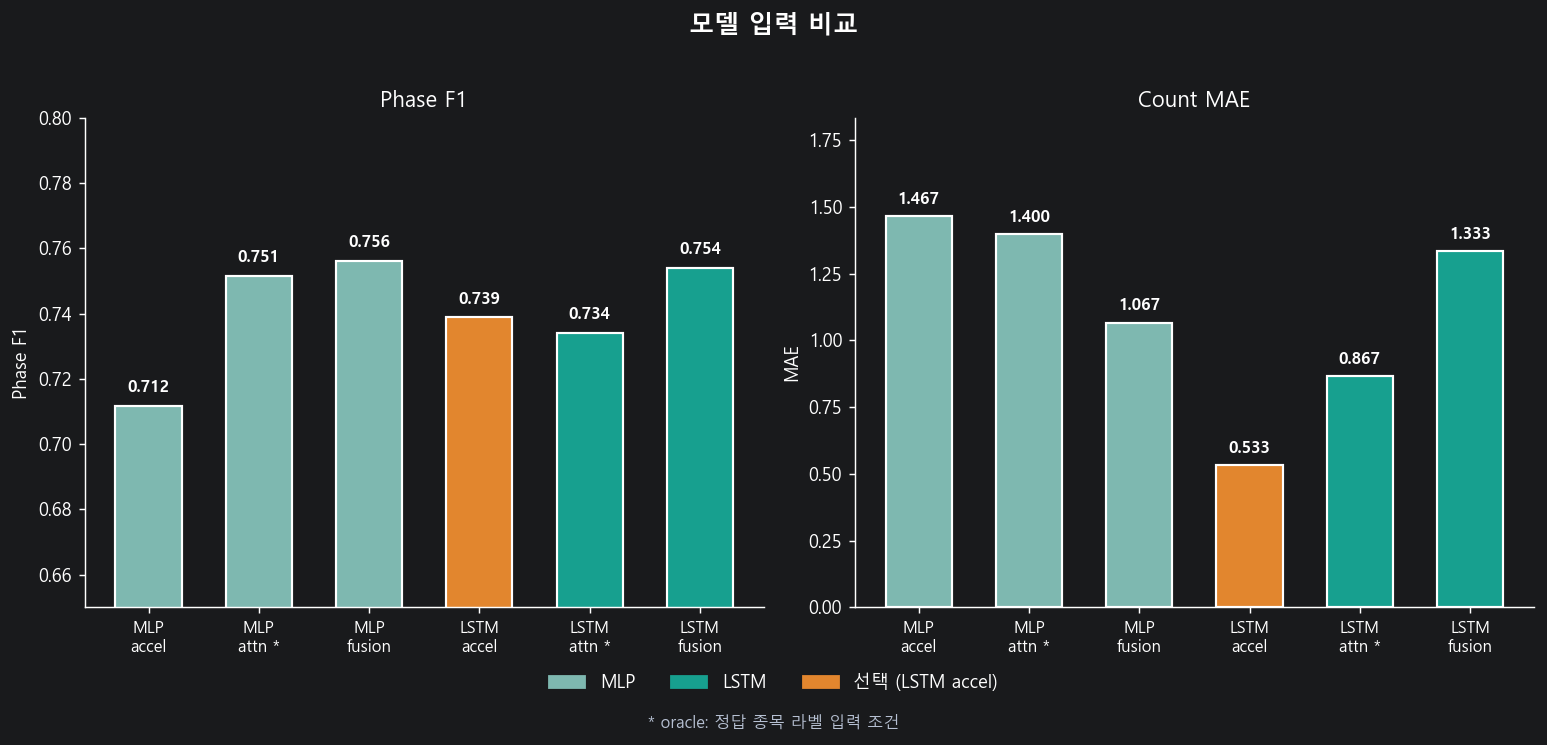

In [47]:
# ── 슬라이드 B: 주요 모델 비교 (frame_metric_reeval 6개) ──────

NAVY   = "#FFFFFF"
TEAL_L = "#7EB8B0"   # MLP 계열
TEAL   = "#17A08F"   # LSTM 계열
ORANGE = "#E2862E"   # 배포 모델
GREY   = "#B6C0D2"

# ── 데이터 추출 ──
reeval = df[df["_source_kind"] == "frame_metric_reeval"].copy()

# OBO 컬럼 탐색
obo_col = next((c for c in df.columns if "obo" in c.lower()), None)
if obo_col:
    reeval["obo_plot"] = reeval[obo_col].map(clean_numeric)
print("reeval rows:", len(reeval))
print(reeval[["model_type_norm", "input_variant",
              "phase_f1_plot", "action_f1_plot",
              "mae_plot"] + (["obo_plot"] if obo_col else [])].to_string())
# ── 모델 순서·레이블·색상 정의 ──
# (model_type_norm, input_variant) → (레이블, oracle여부, 배포여부)
MODEL_CFG = {
    ("mlp",  "acc"):     ("MLP\naccel",    False, False),
    ("mlp",  "attn"):    ("MLP\nattn",     True,  False),
    ("mlp",  "barbell"): ("MLP\nfusion",   False, False),
    ("lstm", "acc"):     ("LSTM\naccel",   False, True),   # 배포
    ("lstm", "attn"):    ("LSTM\nattn",    True,  False),
    ("lstm", "barbell"): ("LSTM\nfusion",  False, False),
}
ORDER = [
    ("mlp","acc"), ("mlp","attn"), ("mlp","barbell"),
    ("lstm","acc"), ("lstm","attn"), ("lstm","barbell"),
]

# 각 모델에서 score 높은 행 1개
rows_b = []
for key in ORDER:
    mt, iv = key
    sub = reeval[
        (reeval["model_type_norm"] == mt) &
        (reeval["input_variant"] == iv)
    ].sort_values("score_plot", ascending=False)
    row = sub.iloc[0].to_dict() if len(sub) else {}
    row["_key"] = key
    rows_b.append(row)

plot_df = pd.DataFrame(rows_b)
plot_df["label"]    = plot_df["_key"].map(lambda k: MODEL_CFG[k][0])
plot_df["is_oracle"]= plot_df["_key"].map(lambda k: MODEL_CFG[k][1])
plot_df["deployed"] = plot_df["_key"].map(lambda k: MODEL_CFG[k][2])

def get_color(key):
    _, is_oracle, deployed = MODEL_CFG[key]
    if deployed:
        return ORANGE
    mt = key[0]
    return TEAL if mt == "lstm" else TEAL_L

plot_df["color"] = plot_df["_key"].map(get_color)

# oracle 표시: 레이블에 * 추가
plot_df["label_disp"] = plot_df.apply(
    lambda r: r["label"] + " *" if r["is_oracle"] else r["label"], axis=1
)

print(plot_df[["label_disp", "phase_f1_plot", "mae_plot",
               "action_f1_plot"] + (["obo_plot"] if obo_col else [])])
# ── 그래프 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("모델 입력 비교",
             fontsize=14, fontweight="bold", color=NAVY, y=1.02)

x      = range(len(plot_df))
labels = plot_df["label_disp"].tolist()
colors = plot_df["color"].tolist()

def annotate(ax, bars, vals, fmt=".3f", pad=0.008):
    for b, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(b.get_x() + b.get_width() / 2, v + pad,
                    f"{v:{fmt}}", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color=NAVY)

# ── Phase F1 ──
ax = axes[0]
vals = plot_df["phase_f1_plot"].tolist()
bars = ax.bar(x, vals, color=colors, width=0.6,
              edgecolor="white", linewidth=1.2)
ax.set_title("Phase F1", fontsize=12, color=NAVY)
ax.set_ylim(0.65, 0.80)
ax.set_ylabel("Phase F1", fontsize=10)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
annotate(ax, bars, vals, pad=0.003)

# ── Count MAE ──
ax = axes[1]
vals2 = plot_df["mae_plot"].tolist()
bars2 = ax.bar(x, vals2, color=colors, width=0.6,
               edgecolor="white", linewidth=1.2)
ax.set_title("Count MAE", fontsize=12, color=NAVY)
ax.set_ylim(0, max([v for v in vals2 if pd.notna(v)] or [2]) * 1.25)
ax.set_ylabel("MAE", fontsize=10)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
annotate(ax, bars2, vals2, fmt=".3f", pad=0.03)

# ── 범례 ──
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=TEAL_L, label="MLP"),
    Patch(color=TEAL,   label="LSTM"),
    Patch(color=ORANGE, label="선택 (LSTM accel)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.05))
fig.text(0.5, -0.08, "* oracle: 정답 종목 라벨 입력 조건",
         ha="center", fontsize=9, color=GREY, style="italic")

fig.tight_layout()
if SAVE_FIGURES:
    out = FIG_DIR / "ppt_model_comparison.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    print("saved:", out)
plt.show()

saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\model_quality_input_visualization\ppt_mlp_high_only_comparison.png


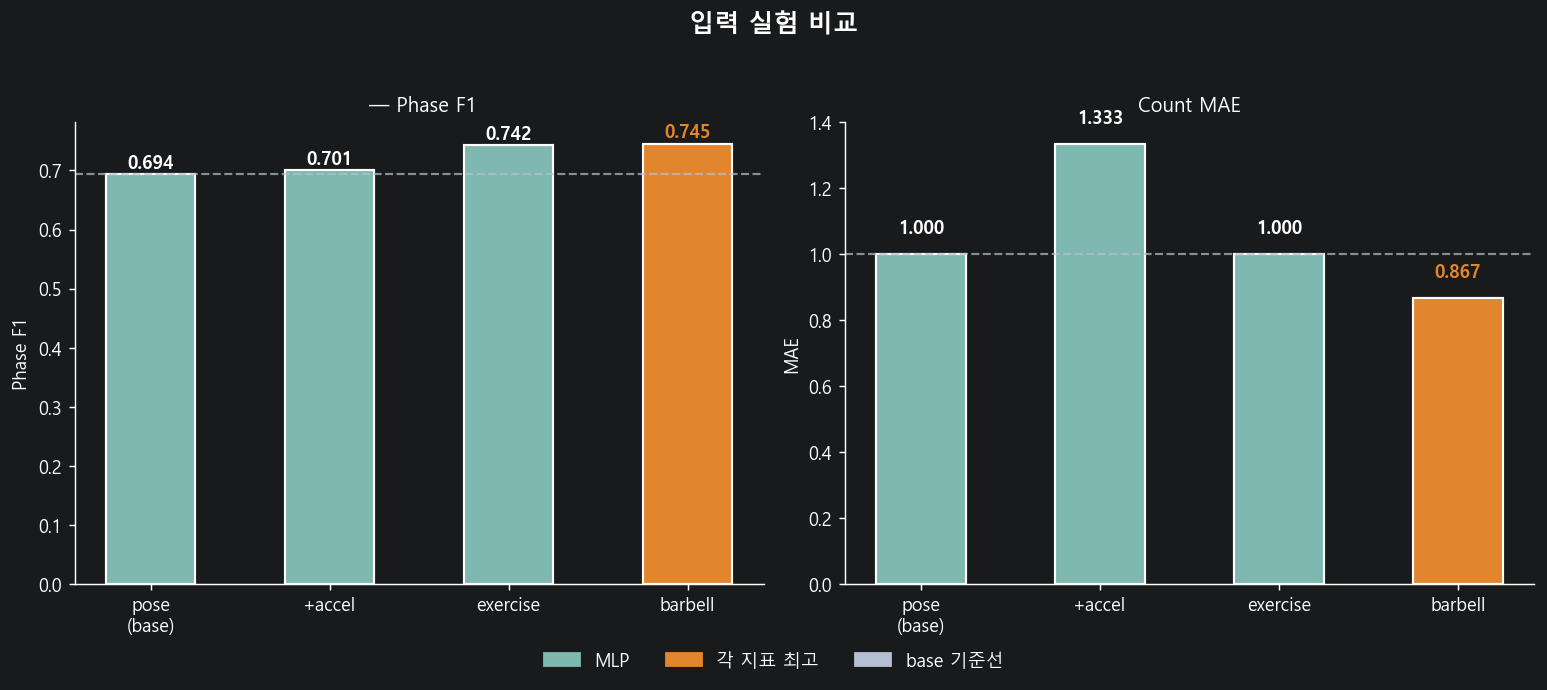

In [48]:
# ── MLP 비교 차트: 고품질(상)만 ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
fig.suptitle("입력 실험 비교", fontsize=14,
             fontweight="bold", color=NAVY, y=1.03)

def draw_group(axes_row, group_df, variant_order, variant_labels,
               title, best_col_min=None):
    plot = (
        group_df[group_df["input_variant"].isin(variant_order)]
        .sort_values(["input_variant", "score_plot"], ascending=[True, False])
        .drop_duplicates("input_variant", keep="first")
        .set_index("input_variant")
        .reindex(variant_order)
        .reset_index()
    )

    xlabels     = [variant_labels.get(v, v) for v in plot["input_variant"]]
    phase_vals  = plot["phase_f1_plot"].tolist()
    mae_vals    = plot["mae_plot"].tolist()

    best_phase = int(pd.Series(phase_vals).idxmax()) \
        if any(pd.notna(v) for v in phase_vals) else None
    best_mae = int(pd.Series(mae_vals).idxmin()) \
        if any(pd.notna(v) for v in mae_vals) else None

    def colors(best_idx):
        return [
            ORANGE if i == best_idx else TEAL_L
            for i in range(len(variant_order))
        ]

    def annotate(ax, bars, vals, best_idx, fmt=".3f", pad=0.004):
        for i, (b, v) in enumerate(zip(bars, vals)):
            if pd.notna(v):
                ax.text(
                    b.get_x() + b.get_width() / 2,
                    v + pad,
                    f"{v:{fmt}}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                    color=ORANGE if i == best_idx else NAVY
                )

    # Phase F1
    ax = axes_row[0]
    bars = ax.bar(
        xlabels,
        phase_vals,
        color=colors(best_phase),
        width=0.5,
        edgecolor="white",
        linewidth=1.2
    )

    if pd.notna(phase_vals[0]):
        ax.axhline(
            phase_vals[0],
            color=GREY,
            linewidth=1.2,
            linestyle="--",
            alpha=0.7
        )

    ax.set_title(f"{title} — Phase F1", fontsize=11, color=NAVY)
    ax.set_ylabel("Phase F1", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    annotate(ax, bars, phase_vals, best_phase, pad=0.004)

    # Count MAE
    ax = axes_row[1]
    bars2 = ax.bar(
        xlabels,
        mae_vals,
        color=colors(best_mae),
        width=0.5,
        edgecolor="white",
        linewidth=1.2
    )

    if pd.notna(mae_vals[0]):
        ax.axhline(
            mae_vals[0],
            color=GREY,
            linewidth=1.2,
            linestyle="--",
            alpha=0.7
        )

    ax.set_title(f"{title}Count MAE",
                 fontsize=11, color=NAVY)
    ax.set_ylabel("MAE", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    annotate(ax, bars2, mae_vals, best_mae, fmt=".3f", pad=0.05)


# ── MLP 데이터 필터링 ──
mlp = df[df["model_type_norm"] == "mlp"].copy()

# ── 고품질(상) 데이터만 사용 ──
g2 = mlp[mlp["dataset_scope"] == "상"]

draw_group(
    axes,
    g2,
    variant_order=["pose", "acc", "attn", "barbell"],
    variant_labels={
        "pose": "pose\n(base)",
        "acc": "+accel",
        "attn": "exercise",
        "barbell": "barbell"
    },
    title=""
)

# ── 범례 ──
from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(color=TEAL_L, label="MLP"),
        Patch(color=ORANGE, label="각 지표 최고"),
        Patch(color=GREY, label="base 기준선"),
    ],
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.05)
)



fig.tight_layout()

if SAVE_FIGURES:
    out = FIG_DIR / "ppt_mlp_high_only_comparison.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    print("saved:", out)

plt.show()

In [53]:
# 종목별 phase F1 컬럼 확인
phase_per_ex = [c for c in df.columns if "phase" in c.lower() and
                any(ex in c.lower() for ex in ["squat", "bench", "deadlift"])]
action_per_ex = [c for c in df.columns if "action" in c.lower() and
                 any(ex in c.lower() for ex in ["squat", "bench", "deadlift"])]

print("종목별 phase 컬럼:", phase_per_ex)
print("종목별 action 컬럼:", action_per_ex)

# 있으면 값 확인
reeval = df[df["_source_kind"] == "frame_metric_reeval"].copy()
check_cols = phase_per_ex + action_per_ex
print(reeval[["model_type_norm","input_variant"] + check_cols].dropna(how="all").to_string())

종목별 phase 컬럼: ['phase_acc_squat', 'phase_macro_f1_squat', 'phase_acc_benchpress', 'phase_macro_f1_benchpress', 'phase_acc_deadlift', 'phase_macro_f1_deadlift']
종목별 action 컬럼: ['frame_action_acc_squat', 'frame_action_acc_benchpress', 'frame_action_acc_deadlift']
   model_type_norm input_variant  phase_acc_squat  phase_macro_f1_squat  phase_acc_benchpress  phase_macro_f1_benchpress  phase_acc_deadlift  phase_macro_f1_deadlift  frame_action_acc_squat  frame_action_acc_benchpress  frame_action_acc_deadlift
21             mlp           acc         0.835583              0.832755              0.567917                   0.532547            0.338153                 0.170618                0.998451                     1.000000                   0.794378
22             mlp          attn         0.839566              0.836239              0.538163                   0.499281            0.575100                 0.548203                0.995132                     1.000000                   0.755020


  exercise   mean    min    max  range
0      스쿼트  0.825  0.807  0.840  0.033
1    벤치프레스  0.537  0.482  0.601  0.119
2    데드리프트  0.480  0.171  0.656  0.485


AttributeError: 'Axes' object has no attribute 'spine'

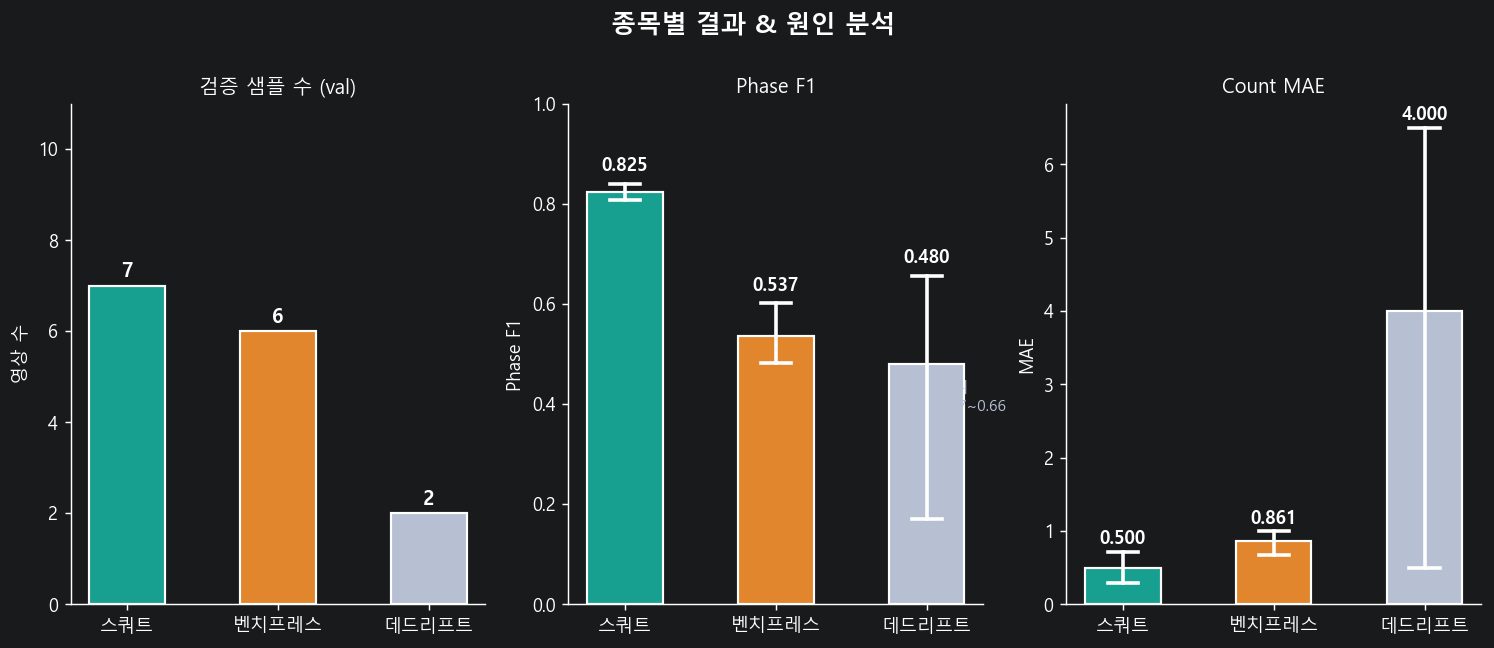

In [60]:
# ── 종목별 결과 & 원인 분석 ────────────────────────────────────

reeval = df[df["_source_kind"] == "frame_metric_reeval"].copy()

EXERCISES = {
    "squat":       ("스쿼트",    "phase_macro_f1_squat"),
    "benchpress":  ("벤치프레스", "phase_macro_f1_benchpress"),
    "deadlift":    ("데드리프트", "phase_macro_f1_deadlift"),
}

# 종목별 min / mean / max (6개 모델 기준)
ex_stats = []
for key, (label, col) in EXERCISES.items():
    vals = pd.to_numeric(reeval[col], errors="coerce").dropna()
    ex_stats.append({
        "exercise": label,
        "mean":  vals.mean(),
        "min":   vals.min(),
        "max":   vals.max(),
        "range": vals.max() - vals.min(),
    })
ex_df = pd.DataFrame(ex_stats)
print(ex_df.round(3).to_string())

# 데이터 분포 (val 샘플 수, 상 품질 비율)
dist = {
    "스쿼트":    {"val": 7,  "high_ratio": 40/89},
    "벤치프레스": {"val": 6,  "high_ratio": 23/94},
    "데드리프트": {"val": 2,  "high_ratio":  8/25},   # ← val=2 핵심
}
dist_df = pd.DataFrame(dist).T.reset_index()
dist_df.columns = ["exercise", "val_n", "high_ratio"]

# ── 그래프 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("종목별 결과 & 원인 분석",
             fontsize=14, fontweight="bold", color=NAVY, y=1.02)

EX_COLORS = [TEAL, ORANGE, GREY]
EX_LABELS = ex_df["exercise"].tolist()

# ── 차트 1: Phase F1 범위 (min~max, 6개 모델) ──
ax = axes[1]
means = ex_df["mean"].tolist()
mins  = ex_df["min"].tolist()
maxs  = ex_df["max"].tolist()
x     = range(len(EX_LABELS))

bars = ax.bar(x, means, color=EX_COLORS,
              width=0.5, edgecolor="white", linewidth=1.2, zorder=3)

# min~max 범위 표시
for i, (mn, mx, mean) in enumerate(zip(mins, maxs, means)):
    ax.plot([i, i], [mn, mx], color=NAVY, linewidth=2, zorder=4)
    ax.plot([i - 0.1, i + 0.1], [mn, mn], color=NAVY, linewidth=2, zorder=4)
    ax.plot([i - 0.1, i + 0.1], [mx, mx], color=NAVY, linewidth=2, zorder=4)
    ax.text(i, mx + 0.018, f"{mean:.3f}",
            ha="center", va="bottom", fontsize=10,
            fontweight="bold", color=NAVY)

# 데드 범위 주석
dead_i = 2
ax.annotate(f"  범위\n  {mins[dead_i]:.2f}~{maxs[dead_i]:.2f}",
            xy=(dead_i, (mins[dead_i]+maxs[dead_i])/2),
            fontsize=8.5, color=MUTE if 'MUTE' in dir() else GREY,
            style="italic", va="center")

ax.set_title("Phase F1",
             fontsize=11, color=NAVY)
ax.set_xticks(list(x))
ax.set_xticklabels(EX_LABELS, fontsize=10)
ax.set_ylabel("Phase F1", fontsize=10)
ax.set_ylim(0, 1.0)
ax.spines[["top", "right"]].set_visible(False)

# ── 차트 2: Val 샘플 수 ──
ax = axes[0]
val_ns = dist_df["val_n"].tolist()
bars2  = ax.bar(dist_df["exercise"], val_ns,
                color=EX_COLORS, width=0.5,
                edgecolor="white", linewidth=1.2)
for b, v in zip(bars2, val_ns):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.08,
            str(int(v)), ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=NAVY)



ax.set_title("검증 샘플 수 (val)", fontsize=11, color=NAVY)
ax.set_ylabel("영상 수", fontsize=10)
ax.set_ylim(0, 11)
ax.spines[["top", "right"]].set_visible(False)

# ── 차트 3: 고품질(상) 비율 ──
# ── 차트 3: 종목별 Count MAE ──
MAE_COLS = {
    "스쿼트":    "mae_squat",
    "벤치프레스": "mae_benchpress",
    "데드리프트": "mae_deadlift",
}

ax = axes[2]

mae_means = [pd.to_numeric(reeval[col], errors="coerce").mean()
             for col in MAE_COLS.values()]
mae_mins  = [pd.to_numeric(reeval[col], errors="coerce").min()
             for col in MAE_COLS.values()]
mae_maxs  = [pd.to_numeric(reeval[col], errors="coerce").max()
             for col in MAE_COLS.values()]

bars3 = ax.bar(list(MAE_COLS.keys()), mae_means,
               color=EX_COLORS, width=0.5,
               edgecolor="white", linewidth=1.2, zorder=3)

for i, (mn, mx, mean) in enumerate(zip(mae_mins, mae_maxs, mae_means)):
    ax.plot([i, i], [mn, mx], color=NAVY, linewidth=2, zorder=4)
    ax.plot([i-0.1, i+0.1], [mn, mn], color=NAVY, linewidth=2, zorder=4)
    ax.plot([i-0.1, i+0.1], [mx, mx], color=NAVY, linewidth=2, zorder=4)
    if pd.notna(mean):
        ax.text(i, mx + 0.05, f"{mean:.3f}",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=NAVY)

ax.set_title("Count MAE", fontsize=11, color=NAVY)
ax.set_ylabel("MAE", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spine

In [61]:
print(
    reeval[[
        "model_type_norm",
        "input_variant",
        "phase_f1_plot",
        "mae_plot"
    ]].round(3).to_string()
)

   model_type_norm input_variant  phase_f1_plot  mae_plot
21             mlp           acc          0.712     1.467
22             mlp          attn          0.751     1.400
23             mlp       barbell          0.756     1.067
24            lstm           acc          0.739     0.533
25            lstm          attn          0.734     0.867
26            lstm       barbell          0.754     1.333


## 6. 현재 phase aux 실험 상태 확인

`quality_high_phase_aux_inputs`는 실험이 끝나면 자동으로 `ablation_results.json`이 생긴다.  
아직 없으면 manifest/status만 확인한다.

In [50]:
aux_root = EXP_ROOT / "quality_high_phase_aux_inputs"
aux_rows = []
if aux_root.exists():
    for manifest_path in sorted(aux_root.glob("*/quality_run_manifest.json")):
        manifest = load_json(manifest_path)
        aux_rows.append({
            "run_dir": str(manifest_path.parent),
            "status": manifest.get("status"),
            "num_results": len(manifest.get("results", [])) if isinstance(manifest.get("results"), list) else 0,
            "created_at_utc": manifest.get("created_at_utc"),
        })
aux_status_df = pd.DataFrame(aux_rows).sort_values("run_dir", ascending=False) if aux_rows else pd.DataFrame()
aux_status_df.head(10)

,run_dir,status,num_results,created_at_utc
4,C:\Users\kojy1\PycharmProjects\capstone\phase_...,started,0,20260617T144411Z
3,C:\Users\kojy1\PycharmProjects\capstone\phase_...,started,0,20260617T141642Z
2,C:\Users\kojy1\PycharmProjects\capstone\phase_...,dry_run,0,20260617T141606Z
1,C:\Users\kojy1\PycharmProjects\capstone\phase_...,dry_run,0,20260617T141156Z
0,C:\Users\kojy1\PycharmProjects\capstone\phase_...,dry_run,0,20260617T141133Z


## 7. 결과 저장

아래 셀은 이 노트북에서 정리한 표를 CSV로 저장한다.

In [51]:
quality_csv = FIG_DIR / "quality_mlp_metrics.csv"
input_csv = FIG_DIR / "input_comparison_metrics.csv"

quality_df.to_csv(quality_csv, index=False, encoding="utf-8-sig")
input_df.to_csv(input_csv, index=False, encoding="utf-8-sig")

print("saved:", quality_csv)
print("saved:", input_csv)

saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\model_quality_input_visualization\quality_mlp_metrics.csv
saved: C:\Users\kojy1\PycharmProjects\capstone\report_figures\model_quality_input_visualization\input_comparison_metrics.csv
